In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb


In [ ]:
n = 3        # Number of questions
p = 1/4      # Probability of correct answer


In [ ]:
x_values = np.arange(0, n+1)
print("Possible values of X:", x_values)


Possible values of X: [0 1 2 3]


In [ ]:
def binomial_pmf(x, n, p):
    return comb(n, x) * (p**x) * ((1-p)**(n-x))


In [ ]:
pmf_values = []

for x in x_values:
    prob = binomial_pmf(x, n, p)
    pmf_values.append(prob)

print("PMF Values:")
for x, prob in zip(x_values, pmf_values):
    print(f"P(X = {x}) = {prob:.4f}")


PMF Values:
P(X = 0) = 0.4219
P(X = 1) = 0.4219
P(X = 2) = 0.1406
P(X = 3) = 0.0156


In [ ]:
expected_value = 0

for x, prob in zip(x_values, pmf_values):
    expected_value += x * prob

print("\nExpected Value E(X):", expected_value)



Expected Value E(X): 0.75


In [ ]:
num_trials = 100000   # Number of students

results = []

for _ in range(num_trials):

    # Each question: 1 = correct, 0 = wrong
    answers = np.random.choice([1, 0], size=n, p=[p, 1-p])

    total_correct = sum(answers)
    results.append(total_correct)


In [ ]:
experimental_pmf = []

for x in x_values:
    count = results.count(x)
    experimental_pmf.append(count / num_trials)

print("\nExperimental PMF:")
for x, prob in zip(x_values, experimental_pmf):
    print(f"P(X = {x}) ≈ {prob:.4f}")



Experimental PMF:
P(X = 0) ≈ 0.4207
P(X = 1) ≈ 0.4225
P(X = 2) ≈ 0.1418
P(X = 3) ≈ 0.0150


In [ ]:
experimental_mean = np.mean(results)

print("\nTheoretical Mean:", expected_value)
print("Experimental Mean:", experimental_mean)



Theoretical Mean: 0.75
Experimental Mean: 0.7511


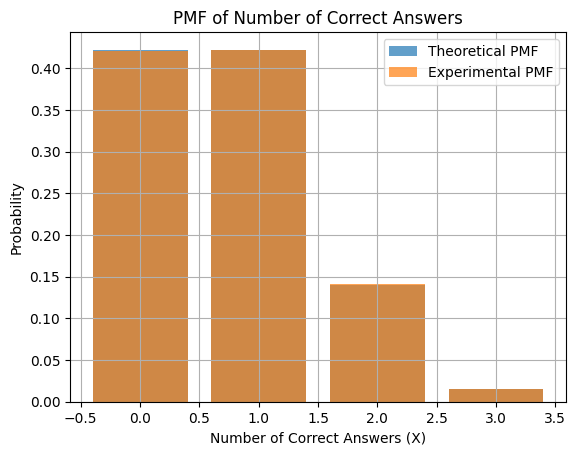

In [ ]:
plt.bar(x_values, pmf_values, alpha=0.7, label="Theoretical PMF")
plt.bar(x_values, experimental_pmf, alpha=0.7, label="Experimental PMF")

plt.xlabel("Number of Correct Answers (X)")
plt.ylabel("Probability")
plt.title("PMF of Number of Correct Answers")

plt.legend()
plt.grid(True)

plt.show()
